In [ ]:
!pip install numpy==1.24.3

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import seaborn as sns
import itertools

from scipy.linalg import LinAlgError
from scipy import stats
from scipy.stats import gaussian_kde, norm

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_squared_error
from math import sqrt
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

https://www.statology.org/dickey-fuller-test-python/
https://www.javatpoint.com/arima-model-in-python


In [ ]:
temp=pd.read_csv('GlobalLandTemperaturesByCountry.csv')
temp.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,Country
0,1743-11-01,4.384,2.294,Åland
1,1743-12-01,NaN,NaN,Åland
2,1744-01-01,NaN,NaN,Åland
3,1744-02-01,NaN,NaN,Åland
4,1744-03-01,NaN,NaN,Åland


In [ ]:
temp.tail()

,dt,AverageTemperature,AverageTemperatureUncertainty,Country
577457,2013-05-01,19.059,1.022,Zimbabwe
577458,2013-06-01,17.613,0.473,Zimbabwe
577459,2013-07-01,17.000,0.453,Zimbabwe
577460,2013-08-01,19.759,0.717,Zimbabwe
577461,2013-09-01,NaN,NaN,Zimbabwe


In [ ]:
print(temp.columns)

Index(['dt', 'AverageTemperature', 'AverageTemperatureUncertainty', 'Country'], dtype='object')


In [ ]:
temp.dtypes

,0
dt,object
AverageTemperature,float64
AverageTemperatureUncertainty,float64
Country,object


In [ ]:
temp=pd.read_csv('GlobalLandTemperaturesByCountry.csv',parse_dates=['dt'])
temp

,dt,AverageTemperature,AverageTemperatureUncertainty,Country
0,1743-11-01,4.384,2.294,Åland
1,1743-12-01,NaN,NaN,Åland
2,1744-01-01,NaN,NaN,Åland
3,1744-02-01,NaN,NaN,Åland
4,1744-03-01,NaN,NaN,Åland
...,...,...,...,...
577457,2013-05-01,19.059,1.022,Zimbabwe
577458,2013-06-01,17.613,0.473,Zimbabwe
577459,2013-07-01,17.000,0.453,Zimbabwe
577460,2013-08-01,19.759,0.717,Zimbabwe


In [ ]:
countries=temp['Country'].unique()
print(countries)

['Åland' 'Afghanistan' 'Africa' 'Albania' 'Algeria' 'American Samoa'
 'Andorra' 'Angola' 'Anguilla' 'Antarctica' 'Antigua And Barbuda'
 'Argentina' 'Armenia' 'Aruba' 'Asia' 'Australia' 'Austria' 'Azerbaijan'
 'Bahamas' 'Bahrain' 'Baker Island' 'Bangladesh' 'Barbados' 'Belarus'
 'Belgium' 'Belize' 'Benin' 'Bhutan' 'Bolivia'
 'Bonaire, Saint Eustatius And Saba' 'Bosnia And Herzegovina' 'Botswana'
 'Brazil' 'British Virgin Islands' 'Bulgaria' 'Burkina Faso' 'Burma'
 'Burundi' "Côte D'Ivoire" 'Cambodia' 'Cameroon' 'Canada' 'Cape Verde'
 'Cayman Islands' 'Central African Republic' 'Chad' 'Chile' 'China'
 'Christmas Island' 'Colombia' 'Comoros'
 'Congo (Democratic Republic Of The)' 'Congo' 'Costa Rica' 'Croatia'
 'Cuba' 'Curaçao' 'Cyprus' 'Czech Republic' 'Denmark (Europe)' 'Denmark'
 'Djibouti' 'Dominica' 'Dominican Republic' 'Ecuador' 'Egypt'
 'El Salvador' 'Equatorial Guinea' 'Eritrea' 'Estonia' 'Ethiopia' 'Europe'
 'Falkland Islands (Islas Malvinas)' 'Faroe Islands'
 'Federated States Of

In [ ]:
country_list = ['Canada', 'Brazil', 'Congo', 'India', 'United Kingdom', 'United States', 'Swaziland', 'Italy', 'Europe', 'France', 'Japan', 'Russia']
temp['Year'] = temp['dt'].dt.year
temp['Month'] = temp['dt'].dt.month
temp=temp.set_index('dt')


In [ ]:
temp_country=temp[temp['Country'].isin(country_list)]
temp_copy = temp_country.copy()
temp_copy.fillna(method='ffill', inplace=True)
temp_copy

,AverageTemperature,AverageTemperatureUncertainty,Country,Year,Month
dt,,,,,
1832-01-01,24.935,1.372,Brazil,1832,1
1832-02-01,24.505,1.953,Brazil,1832,2
1832-03-01,24.617,1.359,Brazil,1832,3
1832-04-01,23.990,2.013,Brazil,1832,4
1832-05-01,23.124,1.592,Brazil,1832,5
...,...,...,...,...,...
2013-05-01,14.073,0.178,United States,2013,5
2013-06-01,20.198,0.236,United States,2013,6
2013-07-01,22.074,0.152,United States,2013,7


<Axes: xlabel='dt'>

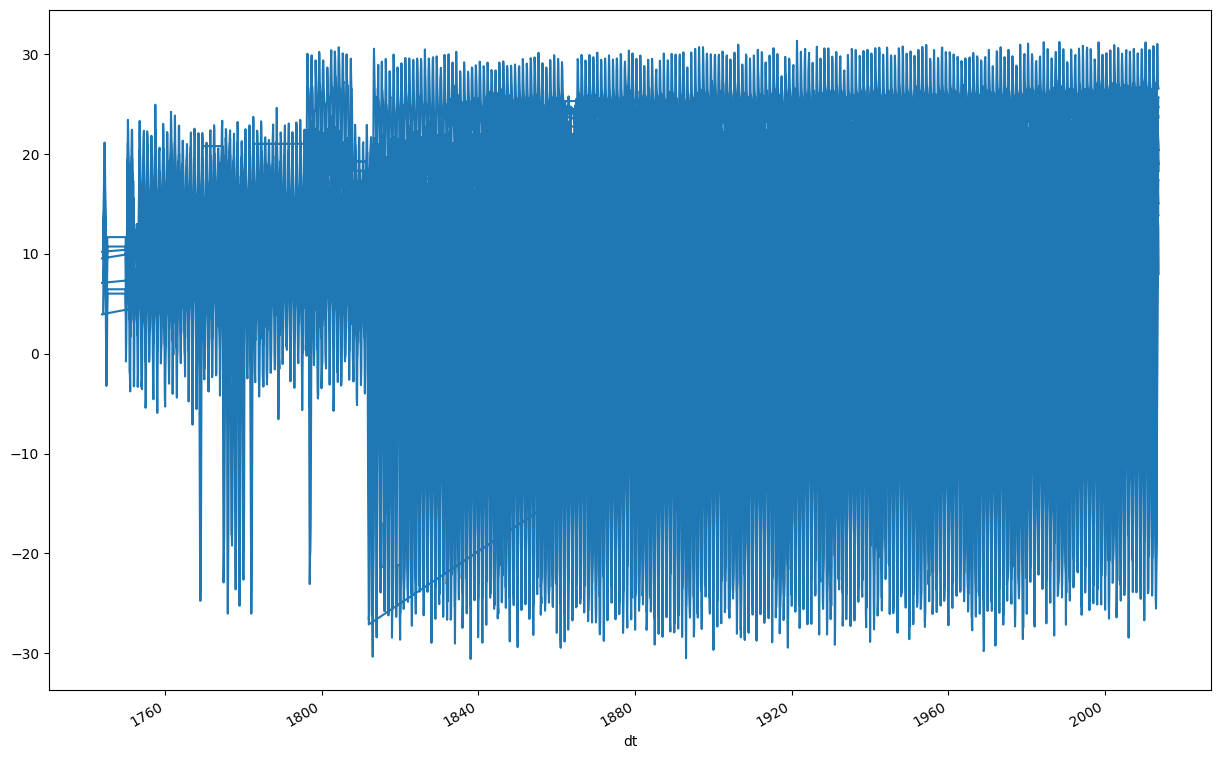

In [ ]:
temp_copy['AverageTemperature'].plot(figsize=(15,10))

In [ ]:
#Augmented dickey fuller test for stationarity check

t=temp_copy['AverageTemperature'].values
fuller_test= adfuller(t)
fuller_out=pd.Series(fuller_test[0:4],index=['Test Stats','p-value','Lags used','No. of observations used'])
print(fuller_out)
for key,value in fuller_test[4].items():
  print('\t%s: %.3f' %(key,value))

if fuller_test[0]<fuller_test[4]['5%']:
  print('Reject H0 - Time series is stationary')
else:
  print('Failed to Reject H0 - Time series is not stationary')

Test Stats                     -3.721231
p-value                         0.003824
Lags used                      51.000000
No. of observations used    31848.000000
dtype: float64
	1%: -3.431
	5%: -2.862
	10%: -2.567
Reject H0 - Time series is stationary


In [ ]:
temp_copy.describe()

,AverageTemperature,AverageTemperatureUncertainty,Year,Month
count,31900.000000,31900.000000,31900.000000,31900.000000
mean,11.448072,1.166606,1898.140313,6.497179
std,11.905859,1.360683,70.736992,3.451312
min,-30.577000,0.053000,1743.000000,1.000000
25%,5.281000,0.256000,1845.000000,3.000000
50%,12.992500,0.583000,1902.000000,6.000000
75%,20.748250,1.645000,1958.000000,9.000000
max,31.329000,12.564000,2013.000000,12.000000


In [ ]:
df=pd.pivot_table(temp_copy,index='Year', columns='Country',values='AverageTemperature',aggfunc='mean')
df

Country,Brazil,Canada,Congo,Europe,France,India,Italy,Japan,Russia,Swaziland,United Kingdom,United States
Year,,,,,,,,,,,,
1743,NaN,NaN,NaN,3.942000,10.203000,NaN,9.538000,NaN,NaN,NaN,7.086000,NaN
1744,NaN,NaN,NaN,8.707250,13.189333,NaN,13.482833,NaN,NaN,NaN,8.955250,NaN
1745,NaN,NaN,NaN,4.100250,10.431250,NaN,9.186250,NaN,NaN,NaN,5.650167,NaN
1746,NaN,NaN,NaN,6.013000,11.672000,NaN,10.728000,NaN,NaN,NaN,6.450000,NaN
1747,NaN,NaN,NaN,6.013000,11.672000,NaN,10.728000,NaN,NaN,NaN,6.450000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2009,25.600583,-4.135083,25.349250,9.150333,13.941667,25.146667,14.052917,12.933833,-4.608500,19.293000,9.453333,9.137083
2010,25.812417,-1.887917,25.559417,8.279833,13.115417,25.050833,13.324917,13.215583,-4.520583,19.756333,8.394333,9.505583
2011,25.428917,-3.557083,24.775083,9.384417,14.479583,24.415583,14.173167,12.737750,-3.401583,19.359000,9.907917,9.549917


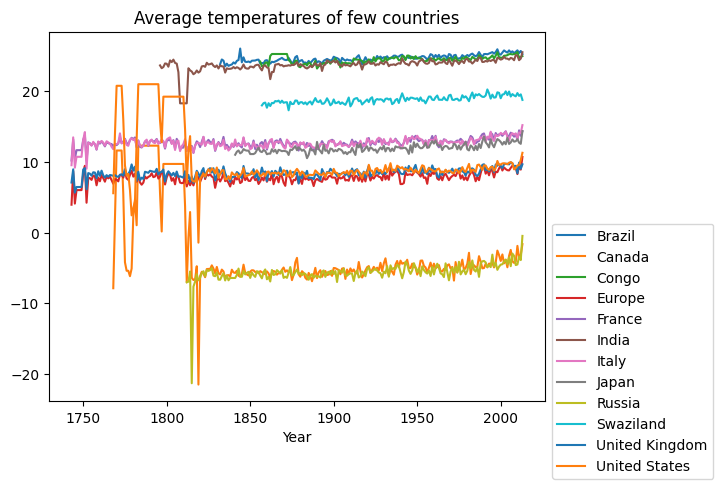

In [ ]:
df.plot()
plt.title('Average temperatures of few countries')
plt.rcParams["figure.figsize"] = (20,12)
plt.legend(bbox_to_anchor =(1, 0.5))

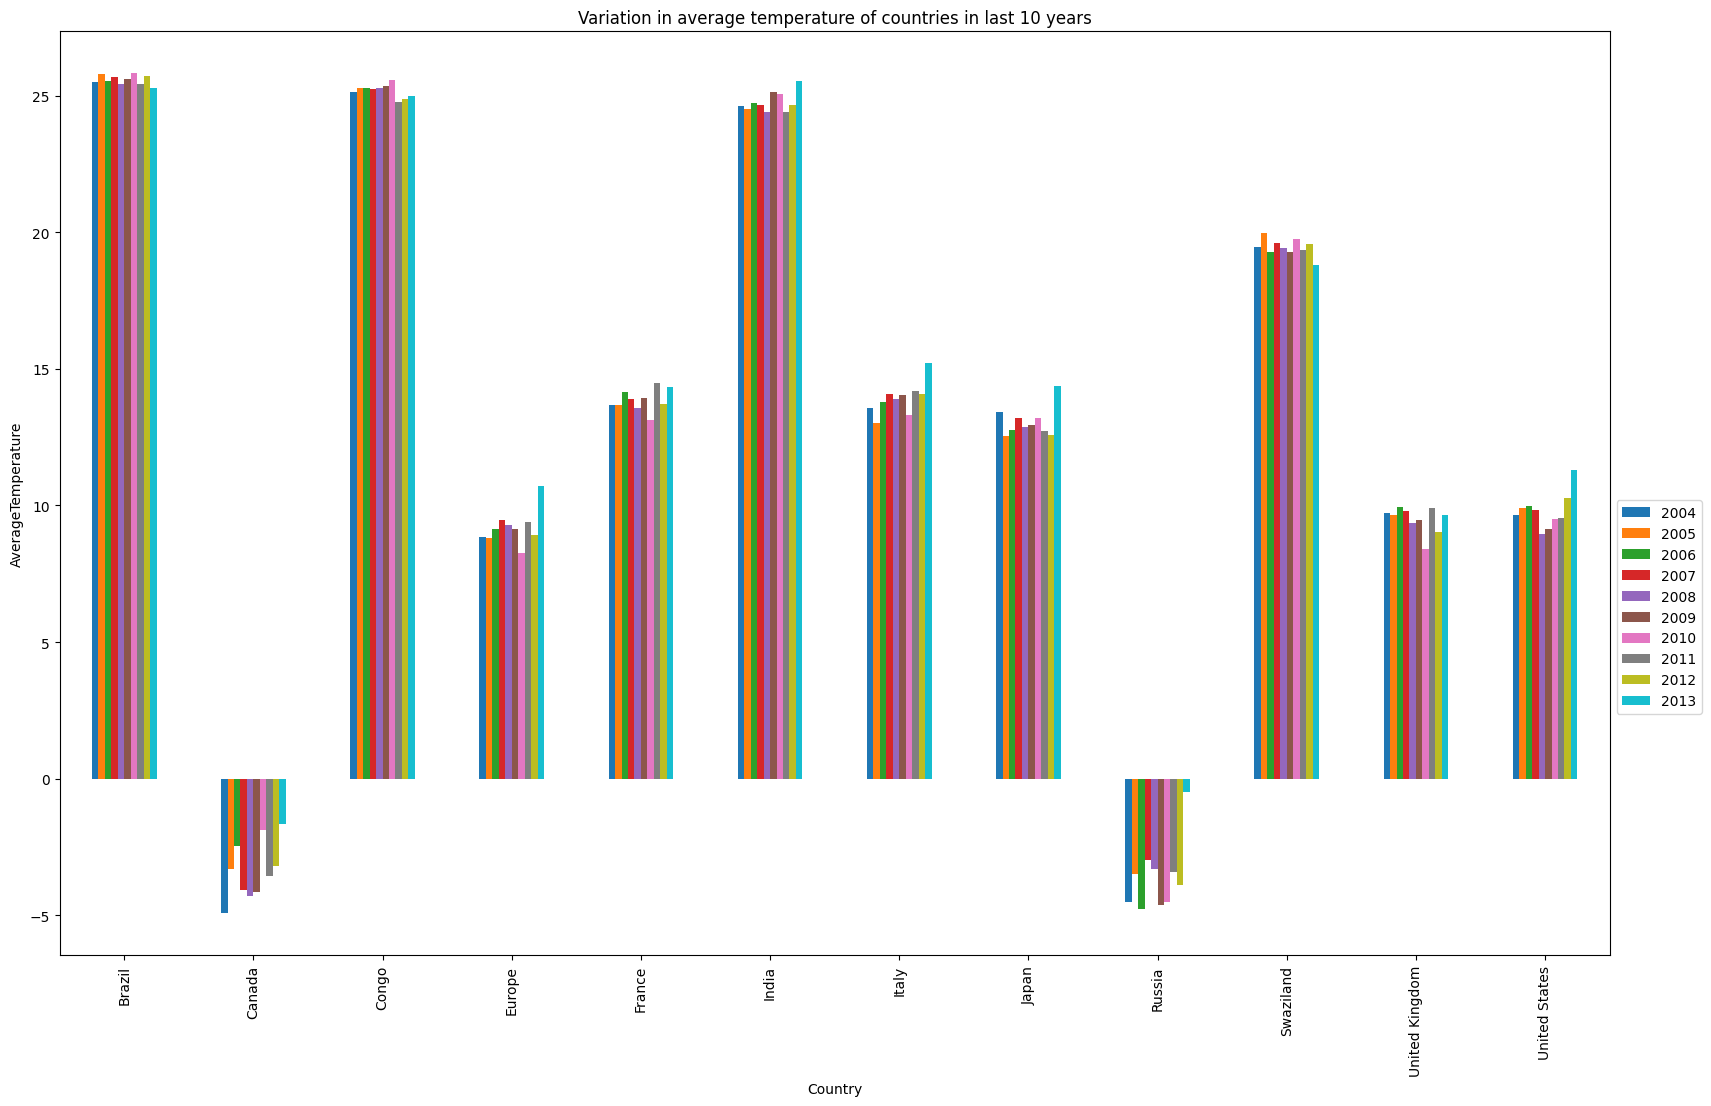

In [ ]:
ax = df[-10:].T.plot(kind='bar', ylabel='AverageTemperature')
plt.title('Variation in average temperature of countries in last 10 years')
plt.rcParams["figure.figsize"] = (12,8)
plt.legend(bbox_to_anchor=(1,0.5))

In [ ]:
countries=pd.read_csv('GlobalLandTemperaturesByCountry.csv',parse_dates=['dt'])
india=temp_copy.loc[temp_copy['Country']=='India',['Year','AverageTemperature']]
india.columns=['year','AvgTemp']
india=india.groupby(pd.Grouper(freq='Y')).mean()
india['year']=india.index.year
india


,year,AvgTemp
dt,,
1796-12-31,1796,23.675250
1797-12-31,1797,23.280750
1798-12-31,1798,23.449083
1799-12-31,1799,23.949417
1800-12-31,1800,23.911917
...,...,...
2009-12-31,2009,25.146667
2010-12-31,2010,25.050833
2011-12-31,2011,24.415583


In [ ]:
import altair as alt
alt.Chart(india).mark_bar().encode(
    x='year:T',
    y='AvgTemp'
)


alt.Chart(...)

In [ ]:
from statsmodels.tsa.stattools import adfuller
from numpy import log

t=india['AvgTemp'].values
fuller_test= adfuller(t)
fuller_out=pd.Series(fuller_test[0:4],index=['Test Stats','p-value','Lags used','No. of observations used'])
print(fuller_out)
for key,value in fuller_test[4].items():
  print('\t%s: %.3f' %(key,value))

if fuller_test[0]<fuller_test[4]['5%']:
  print('Reject H0 - Time series is stationary')
else:
  print('Failed to Reject H0 - Time series is not stationary')

Test Stats                   -2.794173
p-value                       0.059111
Lags used                     6.000000
No. of observations used    211.000000
dtype: float64
	1%: -3.462
	5%: -2.875
	10%: -2.574
Failed to Reject H0 - Time series is not stationary


In [ ]:
#Rolling Statistics test for India temerature
test=pd.DataFrame()
test['year']=india['year']
test['AvgTemp']=india['AvgTemp']
test=test.set_index('year')
print(test)
rollmean=test.rolling(window=12).mean()
rollstd=test.rolling(window=12).std()
print(rollmean,'\n', rollstd)

        AvgTemp
year           
1796  23.675250
1797  23.280750
1798  23.449083
1799  23.949417
1800  23.911917
...         ...
2009  25.146667
2010  25.050833
2011  24.415583
2012  24.640833
2013  25.540111

[218 rows x 1 columns]
        AvgTemp
year           
1796        NaN
1797        NaN
1798        NaN
1799        NaN
1800        NaN
...         ...
2009  24.676896
2010  24.701514
2011  24.681160
2012  24.693062
2013  24.772912

[218 rows x 1 columns] 
        AvgTemp
year          
1796       NaN
1797       NaN
1798       NaN
1799       NaN
1800       NaN
...        ...
2009  0.199208
2010  0.226217
2011  0.240825
2012  0.234393
2013  0.334795

[218 rows x 1 columns]


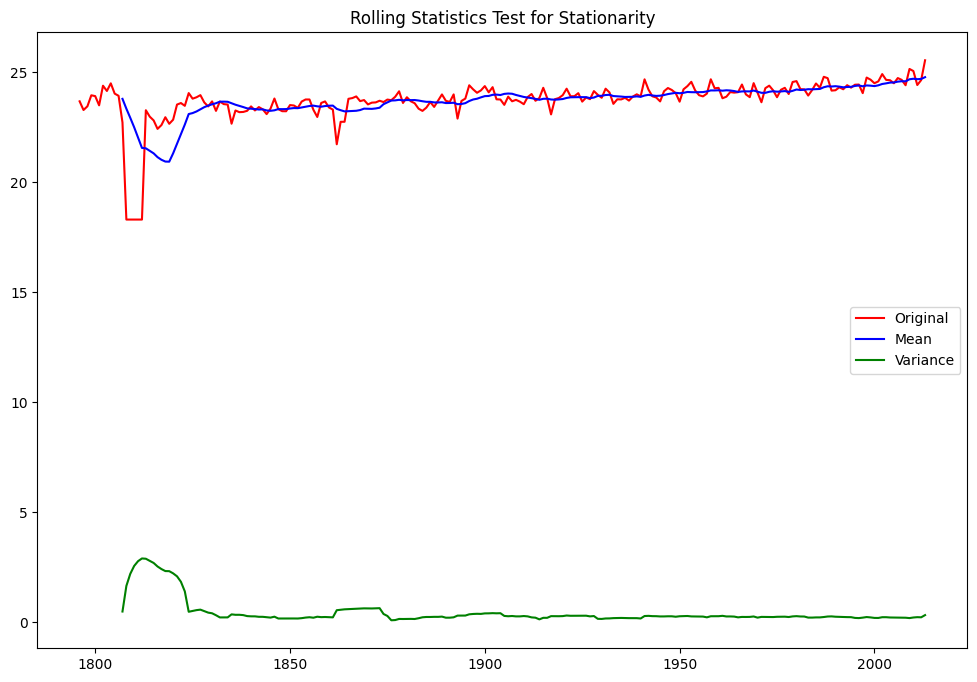

In [ ]:
original=plt.plot(test,color='red',label='Original')
mean=plt.plot(rollmean,color='blue',label='Mean')
std=plt.plot(rollstd,color='green',label='Variance')
plt.rcParams["figure.figsize"]=(10,6)
plt.legend(loc='best')
plt.title('Rolling Statistics Test for Stationarity')
plt.show()

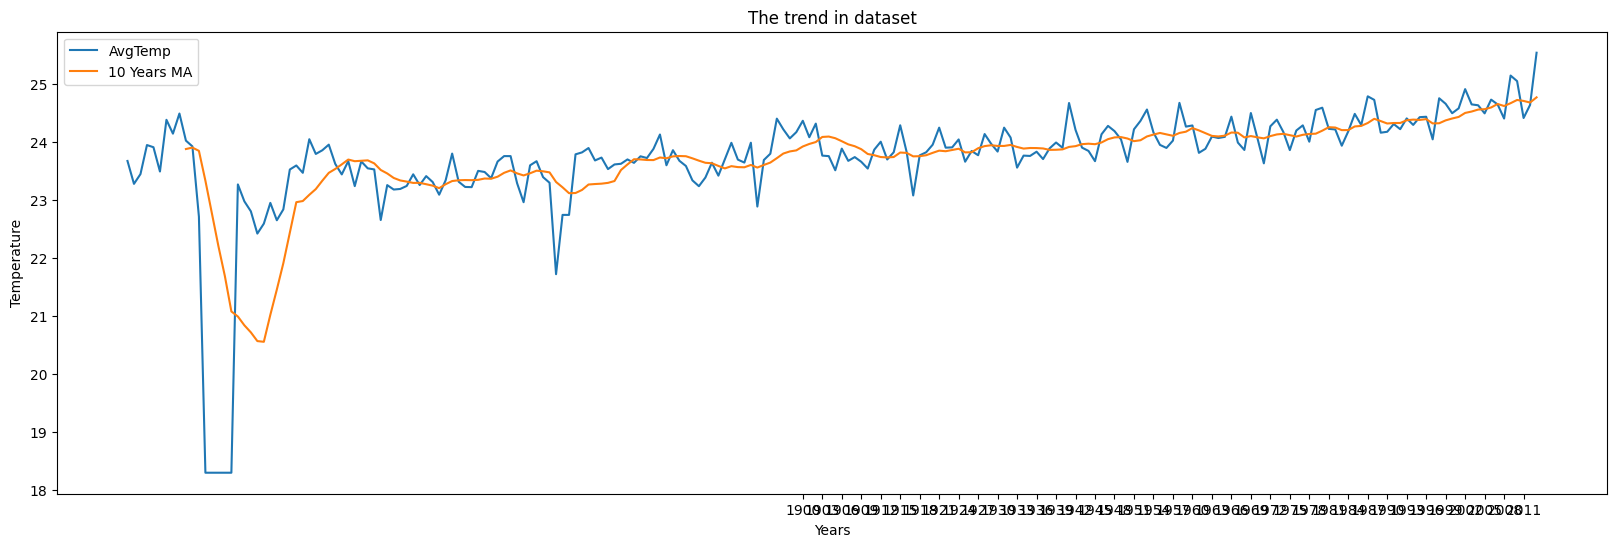

In [ ]:
year_avg = pd.pivot_table(india, values='AvgTemp', index='year', aggfunc='mean')
year_avg['10 Years MA'] = year_avg['AvgTemp'].rolling(10).mean()
year_avg[['AvgTemp','10 Years MA']].plot(figsize=(20,6))
plt.title('The trend in dataset')
plt.xlabel('Years')
plt.ylabel('Temperature')
plt.xticks([x for x in range(1900,2012,3)])
plt.show()

In [ ]:
!pip install pmdarima

In [ ]:
!pip install pmdarima



In [ ]:
from pmdarima import auto_arima
stepwise_fit = auto_arima(temp_copy['AverageTemperature'], trace=True,suppress_warnings=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=121275.839, Time=87.42 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=180119.347, Time=0.92 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=157181.291, Time=2.46 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=164745.797, Time=7.20 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=180117.347, Time=0.39 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=29.13 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=138028.718, Time=47.09 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=120534.763, Time=70.99 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=128331.696, Time=38.19 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=120200.814, Time=96.10 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=125025.662, Time=44.62 sec
 ARIMA(5,1,2)(0,0,0)[0] intercept   : AIC=120751.918, Time=108.48 sec
 ARIMA(4,1,3)(0,0,0)[0] intercept   : AIC=120531.316, Time=122.43 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=121178.867, Time=89.00 sec


In [ ]:
from pmdarima import auto_arima
stepwise_fit_india = auto_arima(test, trace=True,suppress_warnings=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=1.13 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=382.925, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=384.217, Time=0.06 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=384.154, Time=0.14 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=380.973, Time=0.05 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.54 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 1.978 seconds


:)

In [ ]:
print(temp_copy.shape)
train1=temp_copy.iloc[:-30]
test1=temp_copy.iloc[-30:]
print(train1.shape,test1.shape)

(31900, 5)
(31870, 5) (30, 5)


In [ ]:
print(test.shape)
train2=test.iloc[:-30]
test2=test.iloc[-30:]
print(train2.shape,test2.shape)

(218, 1)
(188, 1) (30, 1)


In [ ]:
test1=test1.set_index('Year')
test1

,AverageTemperature,AverageTemperatureUncertainty,Country,Month
Year,,,,
2011,8.582,0.158,United States,4
2011,13.759,0.183,United States,5
2011,19.578,0.251,United States,6
2011,22.722,0.220,United States,7
2011,21.915,0.132,United States,8
2011,17.148,0.110,United States,9
2011,10.490,0.134,United States,10
2011,2.966,0.186,United States,11
2011,-0.635,0.253,United States,12


In [ ]:
train1=train1.set_index('Year')
train1

,AverageTemperature,AverageTemperatureUncertainty,Country,Month
Year,,,,
1832,24.935,1.372,Brazil,1
1832,24.505,1.953,Brazil,2
1832,24.617,1.359,Brazil,3
1832,23.990,2.013,Brazil,4
1832,23.124,1.592,Brazil,5
...,...,...,...,...
2010,3.601,0.155,United States,11
2010,-2.942,0.208,United States,12
2011,-3.507,0.208,United States,1


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
model1 = ARIMA(train1['AverageTemperature'], order=(5, 1, 2))
model1 = model1.fit()
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:     AverageTemperature   No. Observations:                31870
Model:                 ARIMA(5, 1, 2)   Log Likelihood              -59870.515
Date:                Wed, 30 Apr 2025   AIC                         119757.030
Time:                        01:50:57   BIC                         119823.985
Sample:                             0   HQIC                        119778.451
                              - 31870                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.4506      0.003    470.959      0.000       1.445       1.457
ar.L2         -0.7416      0.006   -123.748      0.000      -0.753      -0.730
ar.L3         -0.1058      0.007    -15.790      0.000      -0.119      -0.093
ar.L4          0.1553      0.006     25.997      0.000       0.144       0.167
ar.L5         -0.2180      0.003    -66.209      0.000      -0.224      -0.212
ma.L1         -1.5934      0.002   -848.745      0.000      -1.597      -1.590
ma.L2          0.8282      0.002    517.828      0.000       0.825       0.831
sigma2         2.4142      0.004    546.294      0.000       2.405       2.423
===================================================================================
Ljung-Box (L1) (Q):                   1.71   Jarque-Bera (JB):           1624416.53
Prob(Q):                              0.19   Prob(JB):                         0.00
Heteroskedasticity (H):               1.12   Skew:                            -1.01
Prob(H) (two-sided):                  0.00   Kurtosis:                        37.92
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
train2

,AvgTemp
year,
1796,23.675250
1797,23.280750
1798,23.449083
1799,23.949417
1800,23.911917
...,...
1979,24.553583
1980,24.593083
1981,24.228417


In [ ]:
#from pandas._libs.algos import take_2d_axis1_int32_int32
#test2=take_2d_axis1_int32_int32.set_index('Year')
test2

,AvgTemp
year,
1984,24.185083
1985,24.486333
1986,24.294500
1987,24.789083
1988,24.727750
1989,24.162333
1990,24.178167
1991,24.311750
1992,24.222917


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
model2 = ARIMA(train2['AvgTemp'], order=(0, 1, 0))
model2 = model2.fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                AvgTemp   No. Observations:                  188
Model:                 ARIMA(0, 1, 0)   Log Likelihood                -172.349
Date:                Wed, 30 Apr 2025   AIC                            346.699
Time:                        01:50:57   BIC                            349.930
Sample:                             0   HQIC                           348.008
                                - 188                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.3699      0.009     42.310      0.000       0.353       0.387
===================================================================================
Ljung-Box (L1) (Q):                   0.45   Jarque-Bera (JB):             10278.16
Prob(Q):                              0.50   Prob(JB):                         0.00
Heteroskedasticity (H):               0.12   Skew:                             0.80
Prob(H) (two-sided):                  0.00   Kurtosis:                        39.28
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

<Axes: xlabel='year'>

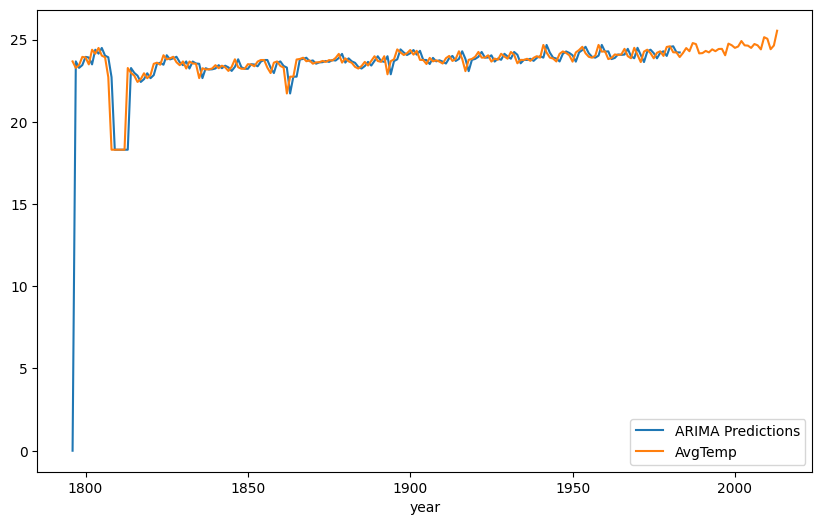

In [ ]:
pred2=model2.predict(typ='levels').rename('ARIMA Predictions')
pred2.plot(legend=True)
test['AvgTemp'].plot(legend=True)

In [ ]:
pred2

,ARIMA Predictions
year,
1796,0.000000
1797,23.675250
1798,23.280750
1799,23.449083
1800,23.949417
...,...
1979,24.007333
1980,24.553583
1981,24.593083


In [ ]:
train2

,AvgTemp
year,
1796,23.675250
1797,23.280750
1798,23.449083
1799,23.949417
1800,23.911917
...,...
1979,24.553583
1980,24.593083
1981,24.228417


In [ ]:
from sklearn.metrics import mean_squared_error
from math import sqrt

print(train2['AvgTemp'].mean())
# pred2 starts from the first forecasted period, while train2 starts from the first period as well
# Align the data, compare pred2 with train2
rmse=sqrt(mean_squared_error(pred2, train2['AvgTemp'].values)) # Align the data by comparing pred2 with train2
print(rmse)

23.594804078014185
1.8301343795530836


In [ ]:
#from statsmodels.tsa.arima_model import ARIMA # This line imports the deprecated class
from statsmodels.tsa.arima.model import ARIMA # This line imports the correct class
model2=ARIMA(test2['AvgTemp'],order=(0,1,0))
model2=model2.fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                AvgTemp   No. Observations:                   30
Model:                 ARIMA(0, 1, 0)   Log Likelihood                 -10.991
Date:                Wed, 30 Apr 2025   AIC                             23.983
Time:                        01:50:58   BIC                             25.350
Sample:                             0   HQIC                            24.411
                                 - 30                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.1249      0.029      4.274      0.000       0.068       0.182
===================================================================================
Ljung-Box (L1) (Q):                   1.58   Jarque-Bera (JB):                 1.43
Prob(Q):                              0.21   Prob(JB):                         0.49
Heteroskedasticity (H):               2.55   Skew:                             0.53
Prob(H) (two-sided):                  0.16   Kurtosis:                         3.26
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

<Axes: xlabel='year'>

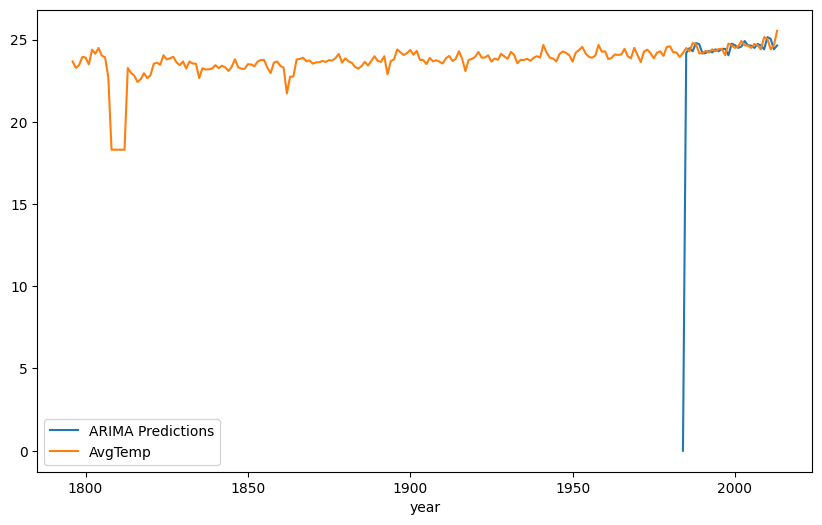

In [ ]:
pred3=model2.predict(typ='levels').rename('ARIMA Predictions')
pred3.plot(legend=True)
test['AvgTemp'].plot(legend=True)

In [ ]:
pred3

,ARIMA Predictions
year,
1984,0.000000
1985,24.185083
1986,24.486333
1987,24.294500
1988,24.789083
1989,24.727750
1990,24.162333
1991,24.178167
1992,24.311750


In [ ]:
from sklearn.metrics import mean_squared_error
from math import sqrt

print(test2['AvgTemp'].mean())
# pred3 and test2 have different lengths and possibly different indices due to the differencing in the ARIMA model.
# Align the data by comparing pred3 with the corresponding values in test2.
# Use the index of pred3 to select the relevant values from test2.
rmse = sqrt(mean_squared_error(pred3, test2['AvgTemp'].loc[pred3.index]))
print(rmse)

24.558237037037035
4.429227785171557


In [ ]:
index_future_dates = pd.date_range(start='2016-12-30', end='2017-01-28', freq='D') # include end date in range
# OR to match pred length:
# index_future_dates = pd.date_range(start='2016-12-30', periods=len(pred), freq='D')

pred = model2.predict(typ='levels').rename('Future ARIMA Predictions')
pred.index = index_future_dates
print(pred)

2016-12-30     0.000000
2016-12-31    24.185083
2017-01-01    24.486333
2017-01-02    24.294500
2017-01-03    24.789083
2017-01-04    24.727750
2017-01-05    24.162333
2017-01-06    24.178167
2017-01-07    24.311750
2017-01-08    24.222917
2017-01-09    24.408667
2017-01-10    24.296417
2017-01-11    24.429750
2017-01-12    24.436917
2017-01-13    24.047333
2017-01-14    24.755417
2017-01-15    24.659833
2017-01-16    24.498000
2017-01-17    24.581917
2017-01-18    24.913000
2017-01-19    24.649917
2017-01-20    24.634583
2017-01-21    24.495417
2017-01-22    24.732083
2017-01-23    24.649917
2017-01-24    24.406000
2017-01-25    25.146667
2017-01-26    25.050833
2017-01-27    24.415583
2017-01-28    24.640833
Freq: D, Name: Future ARIMA Predictions, dtype: float64


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Load dataset
df = pd.read_csv('GlobalLandTemperaturesByCountry.csv')

# Filter for India & drop missing
india_df = df[df['Country'] == 'India']
india_df = india_df[['dt', 'AverageTemperature']].dropna()

# Convert to datetime & sort
india_df['dt'] = pd.to_datetime(india_df['dt'])
india_df = india_df.sort_values('dt')
india_df = india_df.set_index('dt')

# Use monthly average
monthly_df = india_df.resample('M').mean()

# Train-test split
train = monthly_df[:'1983']
test = monthly_df['1984':'2013']

# Normalize
scaler = MinMaxScaler()
scaled_train = scaler.fit_transform(train)
scaled_test = scaler.transform(test)

# Create sequences
def create_seq(data, seq_len=12):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

seq_len = 12
X_train, y_train = create_seq(scaled_train, seq_len)
X_test, y_test = create_seq(scaled_test, seq_len)




<ipython-input-3-50ea859e02a4>:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_df = india_df.resample('M').mean()


In [ ]:
# Replace NaNs with 0, or use forward fill / mean if preferred
X_train = np.nan_to_num(X_train)
y_train = np.nan_to_num(y_train)


In [ ]:
# Reshape for RNNs
X_train_rnn = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_rnn = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [ ]:
import os
os.kill(os.getpid(), 9)

In [ ]:
!pip install --upgrade numpy

In [ ]:
from keras.models import Sequential
from keras.layers import LSTM, Dense

lstm_model = Sequential()
lstm_model.add(LSTM(50, return_sequences=False, input_shape=(seq_len, 1)))
lstm_model.add(Dense(1))
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train_rnn, y_train, epochs=100, batch_size=32, verbose=0)

lstm_preds = lstm_model.predict(X_test_rnn)
lstm_preds_inv = scaler.inverse_transform(lstm_preds)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


In [ ]:
from keras.layers import GRU

gru_model = Sequential()
gru_model.add(GRU(50, return_sequences=False, input_shape=(seq_len, 1)))
gru_model.add(Dense(1))
gru_model.compile(optimizer='adam', loss='mse')
gru_model.fit(X_train_rnn, y_train, epochs=100, batch_size=32, verbose=0)

gru_preds = gru_model.predict(X_test_rnn)
gru_preds_inv = scaler.inverse_transform(gru_preds)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# Flatten X for XGBoost (samples, timesteps * features)
X_train_xgb = X_train.reshape(X_train.shape[0], -1)
X_test_xgb = X_test.reshape(X_test.shape[0], -1)

# Convert y to same format
y_train_xgb = y_train

# Clean NaNs from training data
mask = ~np.isnan(y_train_xgb.ravel())
X_train_xgb_clean = X_train_xgb[mask]
y_train_xgb_clean = y_train_xgb[mask]

# Also clean X_test_xgb if it has NaNs (optional but safe)
X_test_xgb_clean = np.nan_to_num(X_test_xgb)


# Fit XGBoost
xgb = XGBRegressor(n_estimators=100)
xgb.fit(X_train_xgb_clean, y_train_xgb_clean.ravel())

xgb_preds = xgb.predict(X_test_xgb_clean)
xgb_preds_inv = scaler.inverse_transform(xgb_preds.reshape(-1, 1))

In [ ]:
print("LSTM Predictions shape:", lstm_preds_inv.shape)
print("GRU Predictions shape:", gru_preds_inv.shape)
print("First 5 LSTM preds:", lstm_preds_inv[:5])
print("First 5 GRU preds:", gru_preds_inv[:5])


LSTM Predictions shape: (344, 1)
GRU Predictions shape: (344, 1)
First 5 LSTM preds: [[16.580355]
 [18.76435 ]
 [23.507507]
 [28.517345]
 [29.777454]]
First 5 GRU preds: [[17.894747]
 [20.143997]
 [24.292843]
 [29.096397]
 [30.164686]]


In [ ]:
true_vals = y_test
true_vals_inv = scaler.inverse_transform(true_vals.reshape(-1, 1))


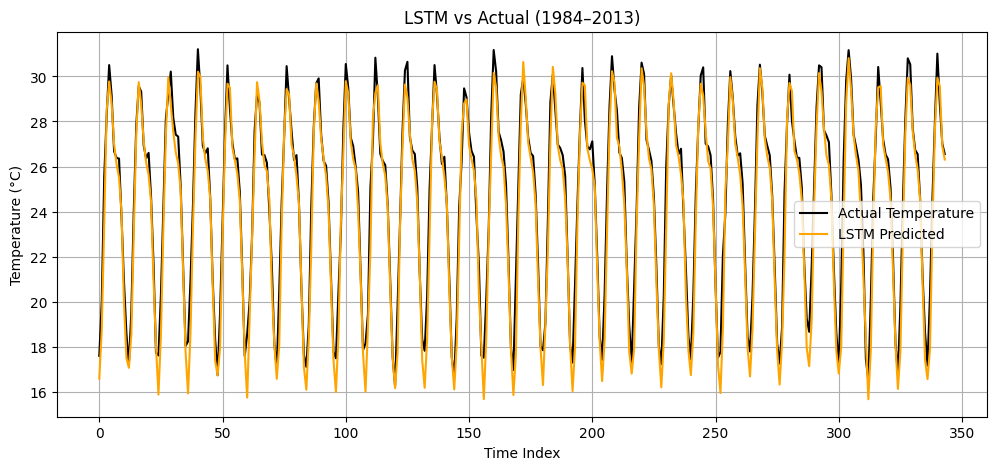

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(true_vals_inv, label='Actual Temperature', color='black')
plt.plot(lstm_preds_inv, label='LSTM Predicted', color='orange')
plt.title('LSTM vs Actual (1984–2013)')
plt.xlabel('Time Index')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()


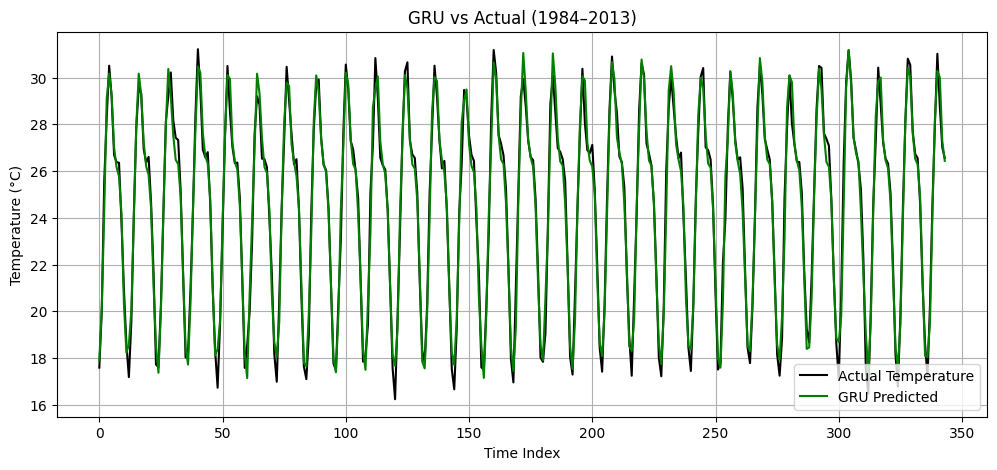

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(true_vals_inv, label='Actual Temperature', color='black')
plt.plot(gru_preds_inv, label='GRU Predicted', color='green')
plt.title('GRU vs Actual (1984–2013)')
plt.xlabel('Time Index')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()


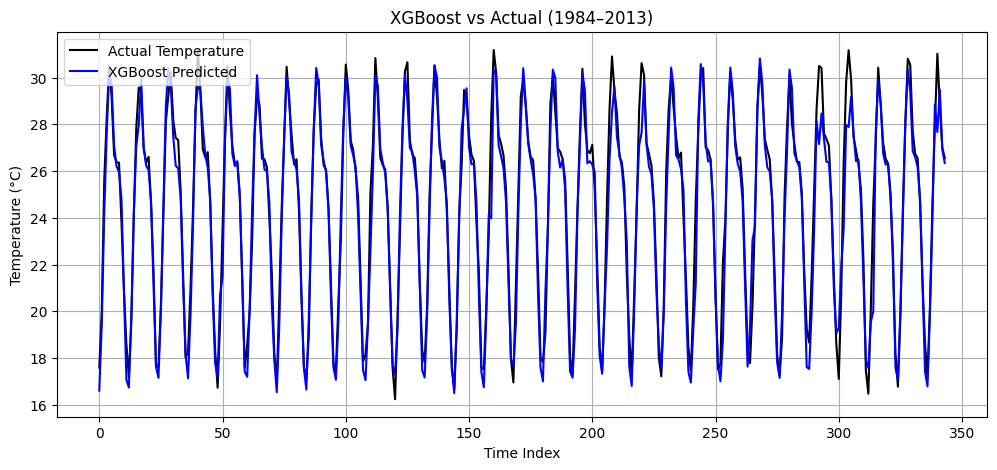

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(true_vals_inv, label='Actual Temperature', color='black')
plt.plot(xgb_preds_inv, label='XGBoost Predicted', color='blue')
plt.title('XGBoost vs Actual (1984–2013)')
plt.xlabel('Time Index')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
index_future_dates = test.index[-len(y_test):]

In [ ]:
import pandas as pd

# Create a DataFrame for Actual vs Predicted values for testing period (1984-2013)
results_df = pd.DataFrame({
    'Date': index_future_dates,  # For testing, use your actual date index from the test set
    'Actual Temperature': true_vals_inv.flatten(),  # Actual values from y_test
    'LSTM Predicted': lstm_preds_inv.flatten(),
    'GRU Predicted': gru_preds_inv.flatten(),
    'XGBoost Predicted': xgb_preds_inv.flatten()
})

# Display the table
results_df.head()  # Display the first 5 rows


,Date,Actual Temperature,LSTM Predicted,GRU Predicted,XGBoost Predicted
0,1985-01-31,17.592,16.580355,17.894747,16.609570
1,1985-02-28,19.996,18.764351,20.143997,19.429266
2,1985-03-31,25.561,23.507507,24.292843,24.152269
3,1985-04-30,28.279,28.517345,29.096397,27.594833
4,1985-05-31,30.506,29.777454,30.164686,30.173380


In [ ]:
# Step 1: Create DataFrame with date index (daily)
df_preds = pd.DataFrame({
    'Actual Temperature': true_vals_inv.flatten(),
    'LSTM Predicted': lstm_preds_inv.flatten(),
    'GRU Predicted': gru_preds_inv.flatten(),
    'XGBoost Predicted': xgb_preds_inv.flatten()
}, index=index_future_dates)  # index_future_dates = y_test.index

# Step 2: Resample to Yearly Average
df_yearly = df_preds.resample('Y').mean()
df_yearly.index = df_yearly.index.year



<ipython-input-45-a507c9c00392>:10: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  df_yearly = df_preds.resample('Y').mean()


In [ ]:
print(df_yearly.head(10))

      Actual Temperature  LSTM Predicted  GRU Predicted  XGBoost Predicted
dt                                                                        
1985           24.486333       23.833902      24.374870          24.134390
1986           24.294500       23.924391      24.446844          24.033098
1987           24.789083       24.020071      24.535248          24.544355
1988           24.727750       23.949394      24.622124          24.352190
1989           24.162333       23.823534      24.423286          24.091919
1990           24.178167       23.782770      24.292673          24.150488
1991           24.311750       23.796194      24.336647          24.091948
1992           24.222917       23.703756      24.293625          24.186907
1993           24.408667       23.816170      24.359076          24.182022
1994           24.296417       23.790176      24.372152          23.921186


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"----- {model_name} Evaluation -----")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")
    print("-----------------------------------\n")


In [ ]:
# Example usage
evaluate_model(true_vals_inv, lstm_preds_inv, "LSTM")
evaluate_model(true_vals_inv, gru_preds_inv, "GRU")
evaluate_model(true_vals_inv, xgb_preds_inv, "XGBoost")


----- LSTM Evaluation -----
MAE  : 0.7517
MSE  : 0.9839
RMSE : 0.9919
R²   : 0.9438
-----------------------------------

----- GRU Evaluation -----
MAE  : 0.5140
MSE  : 0.4384
RMSE : 0.6621
R²   : 0.9750
-----------------------------------

----- XGBoost Evaluation -----
MAE  : 0.6564
MSE  : 0.8898
RMSE : 0.9433
R²   : 0.9492
-----------------------------------

